<a href="https://colab.research.google.com/github/AshSama12/Measurements/blob/master/gmas_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
from pathlib import Path
import os

zip_path = Path("/content/GMAS.yolov8 (1).zip")
extract_path = Path("/content/gmas_classification")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)
print("\nFiles and folders:")

for item in sorted(extract_path.rglob("*")):
    if item.is_dir():
        print("DIR :", item.relative_to(extract_path))
    else:
        print("FILE:", item.relative_to(extract_path))

print("\nImage counts by folder:")

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for folder in sorted([p for p in extract_path.rglob("*") if p.is_dir()]):
    count = sum(1 for f in folder.iterdir() if f.is_file() and f.suffix.lower() in image_exts)
    if count:
        print(folder.relative_to(extract_path), ":", count)

Extracted to: /content/gmas_classification

Files and folders:
FILE: README.dataset.txt
FILE: README.roboflow.txt
FILE: data.yaml
DIR : train
DIR : train/images
FILE: train/images/100_jpeg.rf.0DByTTskcupm7zwZdALP.jpeg
FILE: train/images/101_jpeg.rf.C1LAmtA16biQjGTxFwBl.jpeg
FILE: train/images/102_jpeg.rf.DOXGC44oGKDg9eBayFvn.jpeg
FILE: train/images/103_jpeg.rf.Tte0fqhmjW0XToXX0Mal.jpeg
FILE: train/images/104_jpeg.rf.AWAqNdLhYeeFCtZoe1S8.jpeg
FILE: train/images/105_jpeg.rf.U0K02KUQgrNfZDkJQcpJ.jpeg
FILE: train/images/106_jpeg.rf.vcXL5VFYaV3QmsyzRtLb.jpeg
FILE: train/images/107_jpeg.rf.XnzZStwh0eE0n8xWb9W6.jpeg
FILE: train/images/108_jpeg.rf.e0nZQjSxzijnTRnHZ1FW.jpeg
FILE: train/images/109_jpeg.rf.mWjm8nIDoH2fqOpSQuZn.jpeg
FILE: train/images/10_jpeg.rf.11Kcg8kiunzygA6mR06T.jpeg
FILE: train/images/110_jpeg.rf.AGoYVwdgIYZSj2nnNFgt.jpeg
FILE: train/images/111_jpeg.rf.DdsP3jQKFLfIlJEr7ys6.jpeg
FILE: train/images/112_jpeg.rf.n7BboyV5CvEwIu8n6kX3.jpeg
FILE: train/images/113_jpeg.rf.QKOj6CpBUdY

In [2]:
from pathlib import Path
from collections import Counter
import yaml

base_path = Path("/content/gmas_classification")
images_path = base_path / "train" / "images"
labels_path = base_path / "train" / "labels"

with open(base_path / "data.yaml", "r") as f:
    data = yaml.safe_load(f)

print("Dataset classes:", data.get("names"))
print("Number of classes:", data.get("nc"))

image_files = [f for f in images_path.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]]
label_files = list(labels_path.glob("*.txt"))

print("\nImages:", len(image_files))
print("Labels:", len(label_files))

class_counts = Counter()
image_class_map = {}

for label_file in label_files:
    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    classes = [int(line.split()[0]) for line in lines]
    class_counts.update(classes)

    image_class_map[label_file.stem] = classes

print("\nClass counts:")
for class_id, count in sorted(class_counts.items()):
    name = data["names"][class_id] if class_id < len(data["names"]) else "Unknown"
    print(f"{class_id} = {name}: {count}")

print("\nImages with each class:")

for class_id in sorted(class_counts):
    name = data["names"][class_id] if class_id < len(data["names"]) else "Unknown"
    count = sum(class_id in classes for classes in image_class_map.values())
    print(f"{class_id} = {name}: {count} images")

missing_labels = [
    img.name for img in image_files
    if img.stem not in image_class_map
]

print("\nImages without labels:", len(missing_labels))

Dataset classes: ['body suit', 'sleep suit']
Number of classes: 2

Images: 330
Labels: 330

Class counts:
0 = body suit: 299
1 = sleep suit: 48

Images with each class:
0 = body suit: 293 images
1 = sleep suit: 43 images

Images without labels: 0


In [3]:
import shutil
import random
from pathlib import Path
from collections import Counter

source_images = Path("/content/gmas_classification/train/images")
source_labels = Path("/content/gmas_classification/train/labels")
output_path = Path("/content/garment_classification")

if output_path.exists():
    shutil.rmtree(output_path)

for split in ["train", "val", "test"]:
    for cls in ["body_suit", "sleep_suit"]:
        (output_path / split / cls).mkdir(parents=True, exist_ok=True)

image_class_pairs = []

for label_file in source_labels.glob("*.txt"):
    with open(label_file, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    classes = [int(line.split()[0]) for line in lines]

    if 0 in classes and 1 not in classes:
        cls = "body_suit"
    elif 1 in classes and 0 not in classes:
        cls = "sleep_suit"
    else:
        continue

    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        image_file = source_images / (label_file.stem + ext)
        if image_file.exists():
            image_class_pairs.append((image_file, cls))
            break

random.seed(42)

for cls in ["body_suit", "sleep_suit"]:
    items = [x for x in image_class_pairs if x[1] == cls]
    random.shuffle(items)

    n = len(items)
    train_end = int(n * 0.70)
    val_end = train_end + int(n * 0.15)

    splits = {
        "train": items[:train_end],
        "val": items[train_end:val_end],
        "test": items[val_end:]
    }

    for split, split_items in splits.items():
        for image_file, _ in split_items:
            shutil.copy2(
                image_file,
                output_path / split / cls / image_file.name
            )

print("Classification dataset created at:", output_path)

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["body_suit", "sleep_suit"]:
        count = len(list((output_path / split / cls).glob("*")))
        print(f"{cls}: {count}")

Classification dataset created at: /content/garment_classification

TRAIN
body_suit: 200
sleep_suit: 25

VAL
body_suit: 43
sleep_suit: 5

TEST
body_suit: 44
sleep_suit: 7


In [4]:
!pip install -q ultralytics

from ultralytics import YOLO
import torch

print("Ultralytics:", __import__("ultralytics").__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = YOLO("yolov8n-cls.pt")

results = model.train(
    data="/content/garment_classification",
    epochs=50,
    imgsz=224,
    batch=16,
    patience=10,
    project="/content/runs",
    name="garment_classifier",
    pretrained=True,
    device=0 if torch.cuda.is_available() else "cpu"
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics: 8.4.131
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Ultralytics 8.4.131 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mo

In [5]:
from ultralytics import YOLO
from pathlib import Path
from collections import Counter

model = YOLO("/content/runs/garment_classifier/weights/best.pt")

test_path = Path("/content/garment_classification/test")

results = model.val(
    data="/content/garment_classification",
    split="test",
    imgsz=224,
    batch=16,
    device=0
)

print("\nTest Top-1 Accuracy:", results.top1)
print("Test Top-5 Accuracy:", results.top5)

print("\nTest images:")
for cls in ["body_suit", "sleep_suit"]:
    print(cls, ":", len(list((test_path / cls).glob("*"))))

Ultralytics 8.4.131 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: /content/garment_classification/train... found 225 images in 2 classes ✅ 
val: /content/garment_classification/val... found 48 images in 2 classes ✅ 
test: /content/garment_classification/test... found 51 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1776.1±399.6 MB/s, size: 116.6 KB)
test: Scanning /content/garment_classification/test... 51 images, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 4.6Kit/s 0.0s
test: New cache created: /content/garment_classification/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 4/4 2.2it/s 1.8s
                   all          1          1
Speed: 0.8ms preprocess, 6.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

Test Top-1 Accuracy: 1.0
Test Top-5 Accuracy: 1.0

Test images:
body_suit

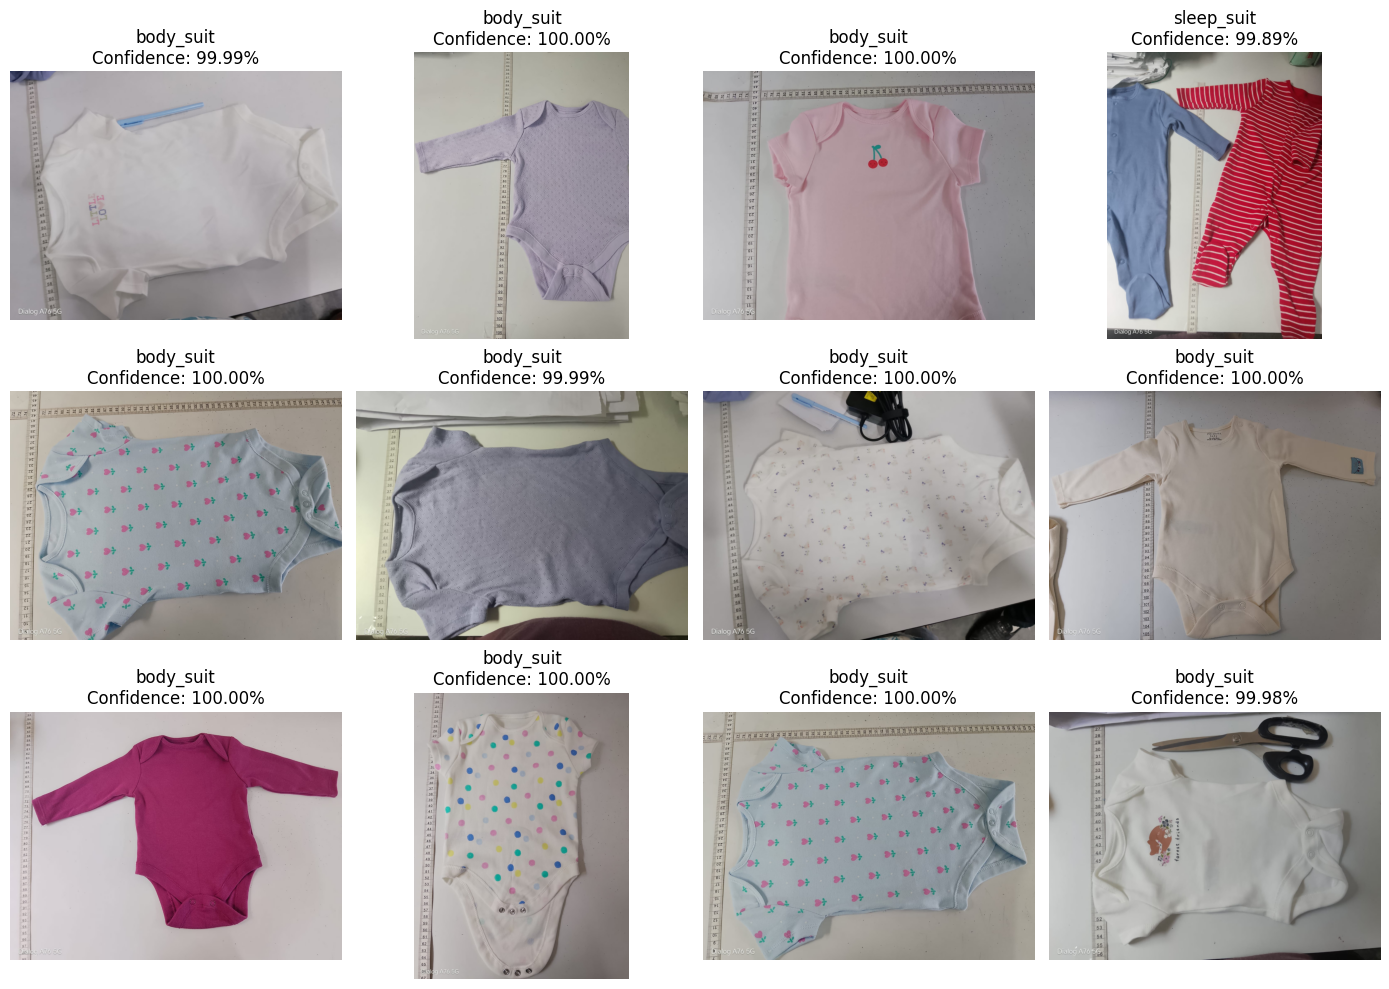

In [6]:
from ultralytics import YOLO
from pathlib import Path
import matplotlib.pyplot as plt
import random

model = YOLO("/content/runs/garment_classifier/weights/best.pt")

test_images = []
for cls in ["body_suit", "sleep_suit"]:
    test_images.extend(list((Path("/content/garment_classification/test") / cls).glob("*")))

random.seed(42)
sample_images = random.sample(test_images, min(12, len(test_images)))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):
    result = model.predict(
        source=str(image_path),
        imgsz=224,
        device=0,
        verbose=False
    )[0]

    pred_id = result.probs.top1
    confidence = float(result.probs.top1conf)
    pred_name = result.names[pred_id]

    image = plt.imread(image_path)
    ax.imshow(image)
    ax.set_title(f"{pred_name}\nConfidence: {confidence:.2%}")
    ax.axis("off")

for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Saving 345.jpeg to 345.jpeg


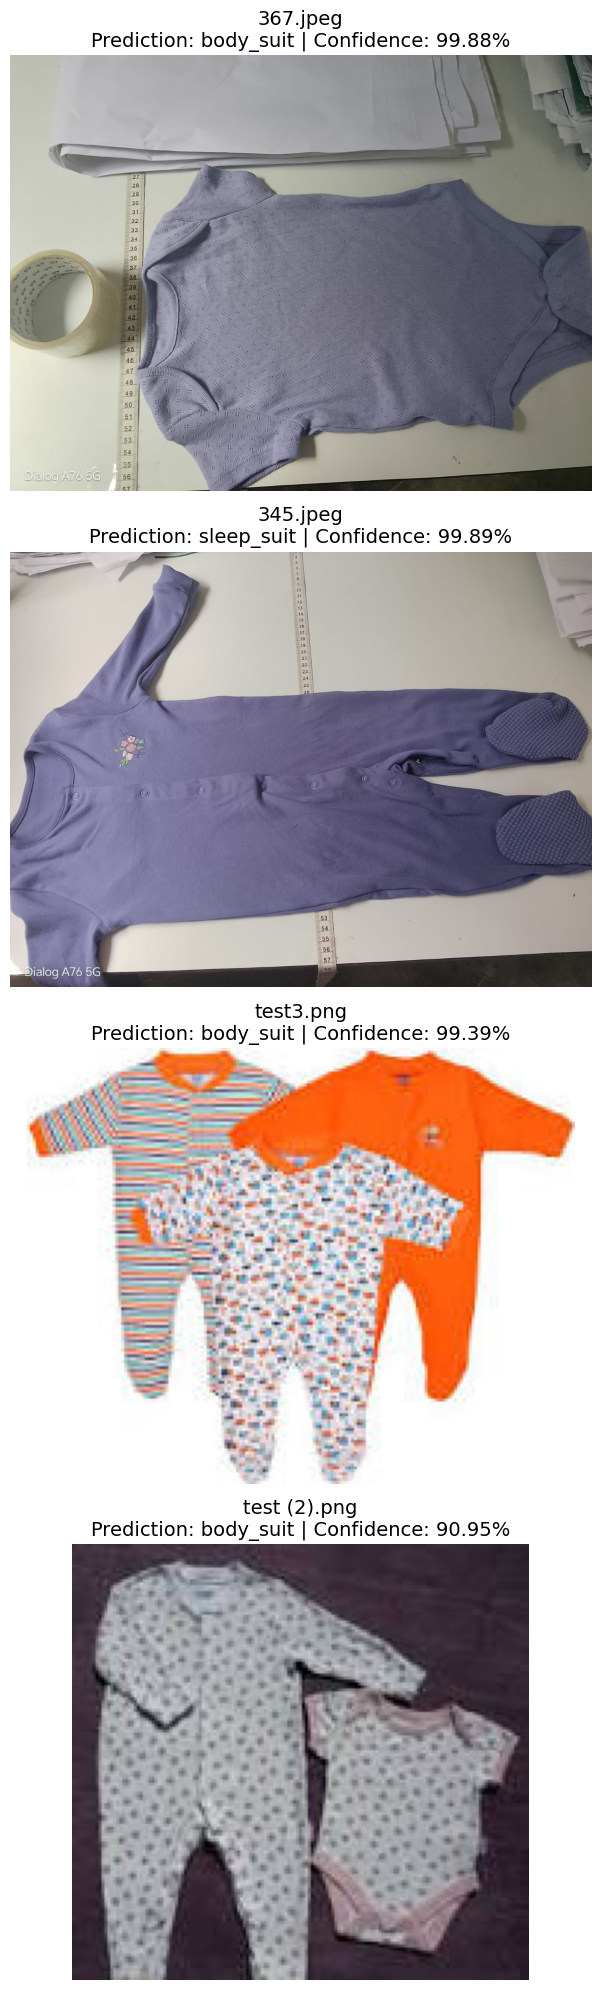

In [10]:
from google.colab import files
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

upload_path = Path("/content/new_garments")
upload_path.mkdir(exist_ok=True)

uploaded = files.upload()

for name, data in uploaded.items():
    with open(upload_path / name, "wb") as f:
        f.write(data)

model = YOLO("/content/runs/garment_classifier/weights/best.pt")

image_files = [
    f for f in upload_path.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
]

fig, axes = plt.subplots(
    len(image_files),
    1,
    figsize=(10, 5 * len(image_files))
)

if len(image_files) == 1:
    axes = [axes]

for ax, image_path in zip(axes, image_files):
    result = model.predict(
        source=str(image_path),
        imgsz=224,
        device=0,
        verbose=False
    )[0]

    pred_id = result.probs.top1
    confidence = float(result.probs.top1conf)
    pred_name = result.names[pred_id]

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(
        f"{image_path.name}\nPrediction: {pred_name} | Confidence: {confidence:.2%}",
        fontsize=14
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Saving 352.jpeg to 352.jpeg


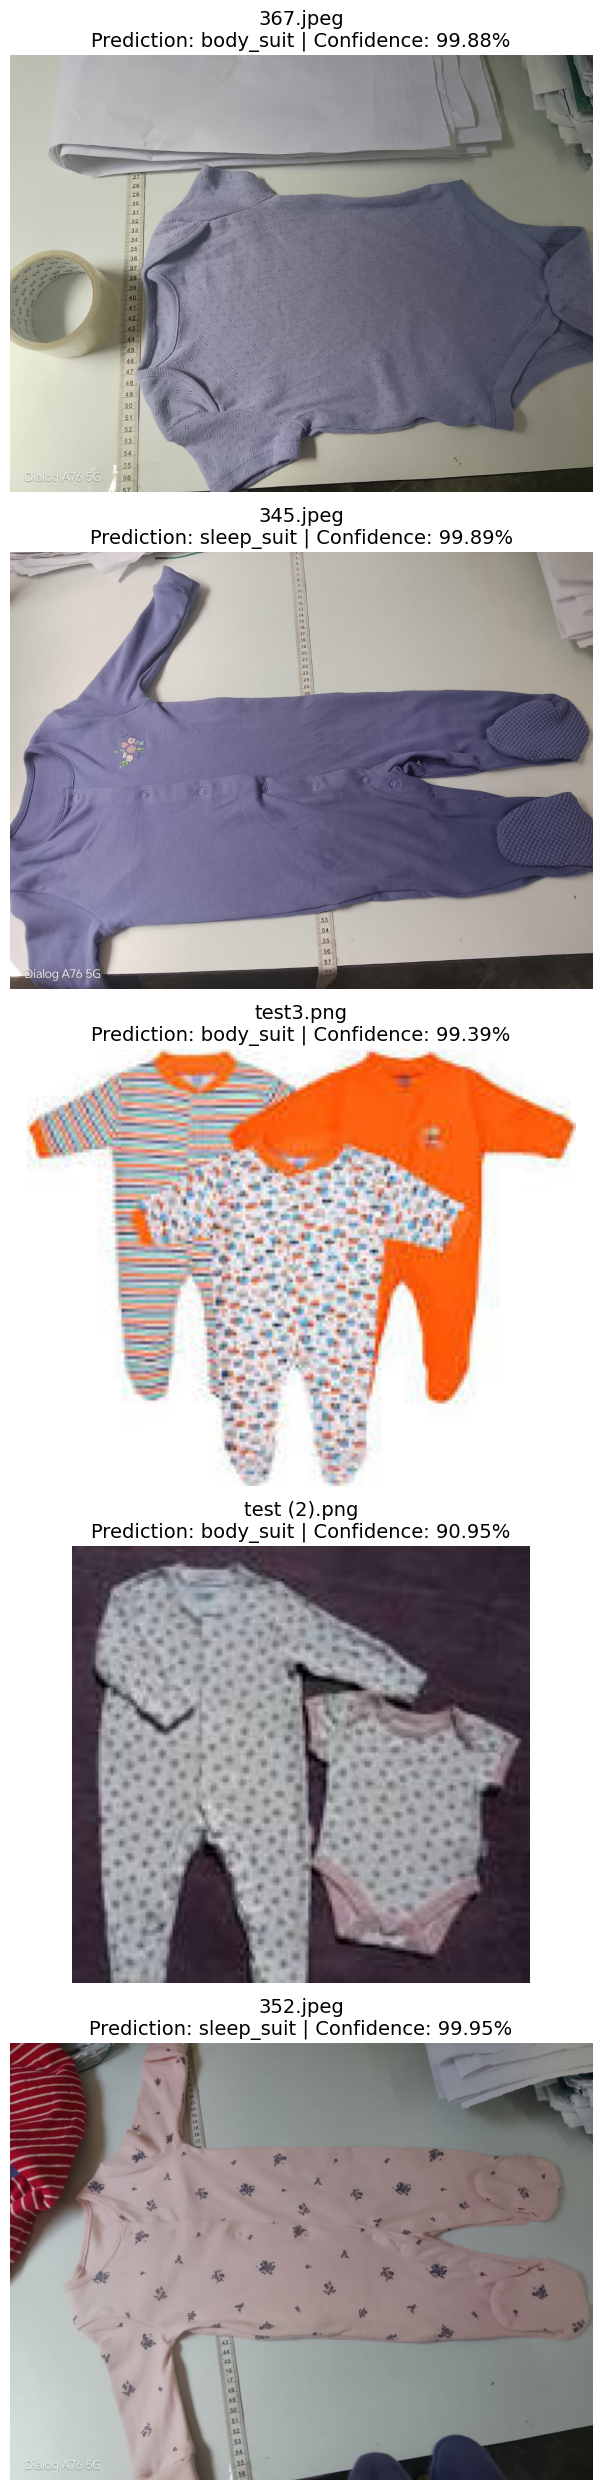

In [11]:
from google.colab import files
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

upload_path = Path("/content/new_garments")
upload_path.mkdir(exist_ok=True)

uploaded = files.upload()

for name, data in uploaded.items():
    with open(upload_path / name, "wb") as f:
        f.write(data)

model = YOLO("/content/runs/garment_classifier/weights/best.pt")

image_files = [
    f for f in upload_path.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
]

fig, axes = plt.subplots(
    len(image_files),
    1,
    figsize=(10, 5 * len(image_files))
)

if len(image_files) == 1:
    axes = [axes]

for ax, image_path in zip(axes, image_files):
    result = model.predict(
        source=str(image_path),
        imgsz=224,
        device=0,
        verbose=False
    )[0]

    pred_id = result.probs.top1
    confidence = float(result.probs.top1conf)
    pred_name = result.names[pred_id]

    image = Image.open(image_path)

    ax.imshow(image)
    ax.set_title(
        f"{image_path.name}\nPrediction: {pred_name} | Confidence: {confidence:.2%}",
        fontsize=14
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path

for path in [Path("/content/new_garments"), Path("/content/new_test")]:
    print("\n", path)
    if path.exists():
        files = [f for f in path.rglob("*") if f.is_file()]
        print("Files:", len(files))
        for f in files:
            print(f)
    else:
        print("Folder does not exist")


 /content/new_garments
Files: 5
/content/new_garments/367.jpeg
/content/new_garments/345.jpeg
/content/new_garments/test3.png
/content/new_garments/test (2).png
/content/new_garments/352.jpeg

 /content/new_test
Folder does not exist


In [15]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO("/content/runs/garment_classifier/weights/best.pt")

test_images = {
    "367.jpeg": "body_suit",
    "345.jpeg": "sleep_suit",
    "test3.png": "sleep_suit",
    "352.jpeg": "sleep_suit"
}

correct = 0
total = 0

print("Results:\n")

for filename, true_class in test_images.items():
    image_path = Path("/content/new_garments") / filename

    result = model.predict(
        source=str(image_path),
        imgsz=224,
        device=0,
        verbose=False
    )[0]

    predicted_id = result.probs.top1
    predicted_class = result.names[predicted_id]
    confidence = float(result.probs.top1conf)

    is_correct = predicted_class == true_class

    if is_correct:
        correct += 1

    total += 1

    print(f"{filename}")
    print(f"True class      : {true_class}")
    print(f"Predicted class : {predicted_class}")
    print(f"Confidence      : {confidence:.2%}")
    print(f"Correct         : {'YES' if is_correct else 'NO'}")
    print()

accuracy = correct / total

print("=" * 40)
print(f"Total images    : {total}")
print(f"Correct         : {correct}")
print(f"Wrong           : {total - correct}")
print(f"Accuracy        : {accuracy:.2%}")
print("=" * 40)

Results:

367.jpeg
True class      : body_suit
Predicted class : body_suit
Confidence      : 99.88%
Correct         : YES

345.jpeg
True class      : sleep_suit
Predicted class : sleep_suit
Confidence      : 99.89%
Correct         : YES

test3.png
True class      : sleep_suit
Predicted class : body_suit
Confidence      : 99.39%
Correct         : NO

352.jpeg
True class      : sleep_suit
Predicted class : sleep_suit
Confidence      : 99.95%
Correct         : YES

Total images    : 4
Correct         : 3
Wrong           : 1
Accuracy        : 75.00%


In [16]:
from pathlib import Path

model_path = Path("/content/runs/garment_classifier/weights/best.pt")

if model_path.exists():
    print("Model found!")
    print("Path:", model_path)
    print("Size:", model_path.stat().st_size / (1024 * 1024), "MB")
else:
    print("Model not found!")

Model found!
Path: /content/runs/garment_classifier/weights/best.pt
Size: 2.8270339965820312 MB


In [17]:
from google.colab import files

files.download("/content/runs/garment_classifier/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
!pip install -q gradio

In [19]:
from ultralytics import YOLO
import gradio as gr

# Load trained model
model = YOLO("/content/runs/garment_classifier/weights/best.pt")

# Get class names
class_names = model.names

print("Classes:", class_names)


def classify_garment(image):
    if image is None:
        return "Please upload an image.", None

    # Run prediction
    results = model.predict(
        source=image,
        imgsz=224,
        verbose=False
    )

    result = results[0]

    # Classification probabilities
    probs = result.probs

    predicted_class = probs.top1
    confidence = float(probs.top1conf)

    class_name = class_names[predicted_class]

    # Create result text
    prediction = f"{class_name}\nConfidence: {confidence * 100:.2f}%"

    # Probability for each class
    probabilities = {
        class_names[i]: float(probs.data[i])
        for i in range(len(class_names))
    }

    return prediction, probabilities


# Gradio interface
demo = gr.Interface(
    fn=classify_garment,
    inputs=gr.Image(type="numpy", label="Upload Garment Image"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Label(label="Class Probabilities")
    ],
    title="Garment Classification",
    description="Upload a garment image to classify it as Body Suit or Sleep Suit."
)

demo.launch(share=True)

Classes: {0: 'body_suit', 1: 'sleep_suit'}
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fb16016c3c085275f2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
